In [ ]:
# Install necessary packages if they are not already installed
# !pip install numpy opencv-python torch torchvision matplotlib captum scikit-image scikit-learn tqdm

# XAI Pipelines for Thesis Models

This notebook implements distinct XAI pipelines to evaluate the pre-trained medical imaging models available in this repository.
Models supported:
- Late Fusion
- Cross Attention
- Gated Fusion
- Hybrid Transformer
- Mixture of Experts
- ViT

Start by setting up the environment.

In [1]:
import sys
import os

# Add XAIensembler to python path
sys.path.append(os.path.join(os.getcwd(), 'XAIensembler'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision import models, transforms

# Import customized modules from the repo
import XAIensembler.params as params
import XAIensembler.modelarch as modelarch
import XAIensembler.augm as augm
import XAIensembler.thesisArchitecture_LateFusion as thesisArchitecture_LateFusion
import XAIensembler.thesisArchitecture_cnn as thesisArchitecture_cnn
import XAIensembler.thesisArchitecture_ViT as thesisArchitecture_ViT
import XAIensembler.thesisArchitecture_GatedFusion as thesisArchitecture_GatedFusion
import XAIensembler.thesisArchitecture_HybridTransformer as thesisArchitecture_HybridTransformer
import XAIensembler.thesisArchitecture_MoE as thesisArchitecture_MoE
from XAIensembler.segmentXAIensembler import ISIC_Dataset

# Check device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# --- Configuration ---

# We need to ensure we update the specific 'params' module instance that segmentXAIensembler is using.
# Because of import differences (XAIensembler.params vs params), there might be two instances.
import XAIensembler.segmentXAIensembler as seg

# Set paths to local data
root = os.getcwd()
data_root = os.path.join(root, "data")

# Create a config dict to update both module references
config_updates = {
    "root_path": root,
    "mask_train_path": os.path.join(data_root, "masks/train"),
    "image_train_path": os.path.join(data_root, "images/train"),
    "mask_validation_path": os.path.join(data_root, "masks/validation"),
    "image_validation_path": os.path.join(data_root, "images/validation"),
    "mask_test_path": os.path.join(data_root, "masks/test"),
    "image_test_path": os.path.join(data_root, "images/test"),
    "benchmark_out_path": "cenet_XAI_model.th",
    "XAI_methods": ["IntegratedGradients", "DeepLift"],
    # Ensure image_class is one that exists. We have melanoma, nevus, seborrheic_keratosis in data/images/test
    "image_class": "melanoma" 
}

# Apply updates to 'params' (from XAIensembler.params) and 'seg.params'
for key, value in config_updates.items():
    setattr(params, key, value)
    setattr(seg.params, key, value)

print("Configuration updated for both 'params' and 'segmentXAIensembler.params'.")
print(f"Test Images Path: {seg.params.image_test_path}")

# Ensure output directories exist
os.makedirs("out_XAI/overlaid", exist_ok=True)
os.makedirs("out_XAI/masks-late_fusion", exist_ok=True)
os.makedirs("out_XAI/masks-mixture-of-experts", exist_ok=True)

Configuration updated for both 'params' and 'segmentXAIensembler.params'.
Test Images Path: /Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/data/images/test


In [14]:
# --- Helper Function for Visualization ---
def visualize_pipeline_result(original, mask, predicted_mask, predictions_xai, model_name, method_names):
    """
    Visualizes the Original Image, Ground Truth, Predicted Mask, and XAI Explanations.
    """
    n_cols = 3 + len(predictions_xai) # removed +1 as predictions_xai includes ensemble output
    
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    
    # Original
    axes[0].imshow(original)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    # Ground Truth
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')
    
    # Predicted Mask
    axes[2].imshow(predicted_mask, cmap='gray')
    axes[2].set_title(f"Pred: {model_name}")
    axes[2].axis('off')
    
    # Individual Explanations (Inputs to Ensemble)
    
    for i, expl in enumerate(predictions_xai):
        ax_idx = 3 + i
        if i < len(method_names):
            name = method_names[i]
        else:
            name = f"Expl {i}"
            
        expl = np.array(expl)
        
        # Determine shape and normalize for heatmap
        # Possible shapes: (3, H, W), (H, W), (1, H, W)
        
        heatmap = None
        
        if expl.ndim == 2:
             # (H, W) - already a heatmap
             heatmap = np.abs(expl)
        elif expl.ndim == 3:
             if expl.shape[0] in [1, 3]: 
                 # (C, H, W) where C=1 or 3 -> Transpose to (H, W, C)
                 expl_t = np.transpose(expl, (1, 2, 0))
             else:
                 # Assume (H, W, C)
                 expl_t = expl
                 
             # Sum channels if C=3, squeeze if C=1
             heatmap = np.sum(np.abs(expl_t), axis=-1)
        
        if heatmap is not None:
            # Normalize heatmap for clear visualization
            if heatmap.max() > heatmap.min():
                 heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
            
            axes[ax_idx].imshow(heatmap, cmap='jet')
            axes[ax_idx].set_title(name)
            axes[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()

print("Visualization helper defined.")

Visualization helper defined.


## Variant 1: Late Fusion Ensemble Pipeline

This pipeline:
1.  Takes an input image.
2.  Generates `IntegratedGradients` and `DeepLift` explanations using SqueezeNet (Base Model).
3.  Feeds those explanations into the pre-trained `Late Fusion` model.
4.  Produces a segmentation mask and an "ensembled" explanation.

Dataset size: 12
Sample loaded. Items: 4
Loading weights from late_fusion_model.th
Weights loaded for Late Fusion (strict=False)

--- Late Fusion Results ---
Ground Truth Mask Active Pixels: 12676
Max Prediction Probability: 0.6519
Mean Prediction Probability: 0.5780
Predicted Mask Active Pixels (>0.5): 50176
Ensemble Expl Range: [0.0156, 0.6275]


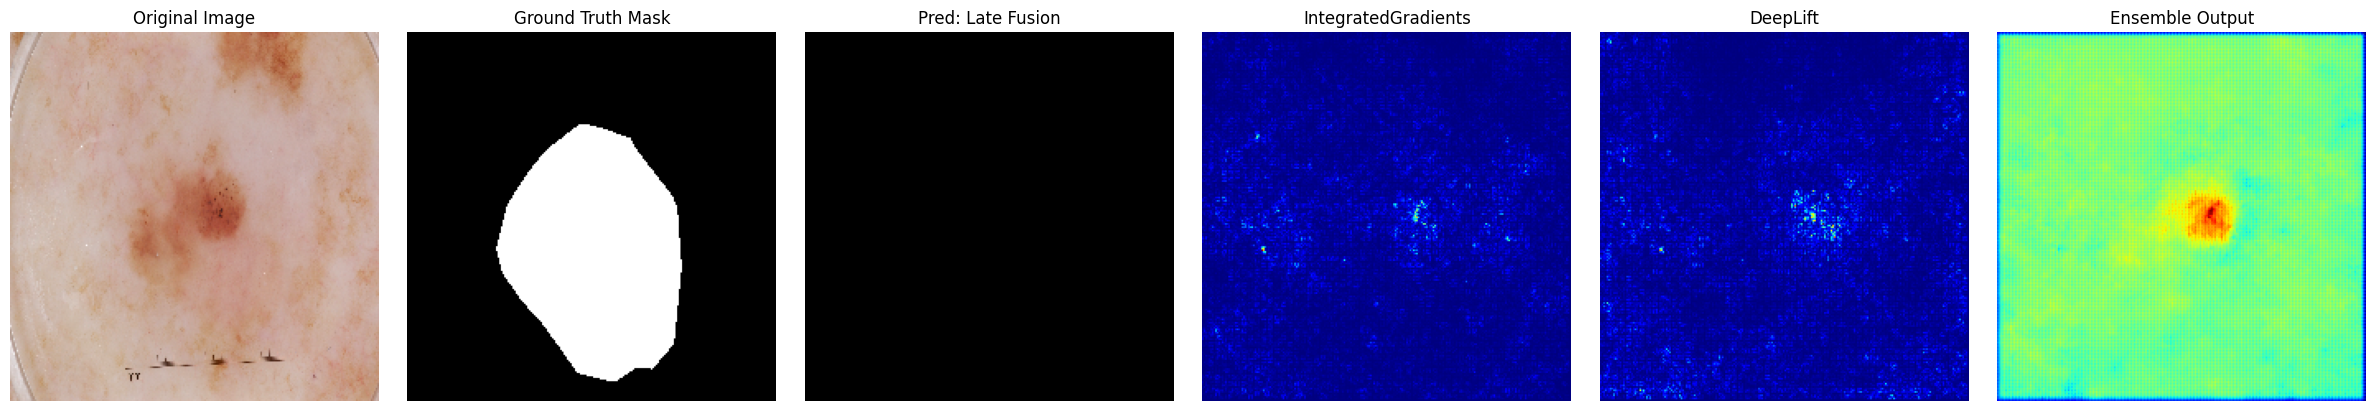

In [15]:
# --- Pipeline Variant 1: Late Fusion ---

# 1. Load Data (Test Set)
# This instantiates the dataset which will generate explanations on-the-fly
dataset = ISIC_Dataset(params, params.root_path, phase="test")
print(f"Dataset size: {len(dataset)}")

# Get one sample
# Returns: (explanations, label_mask, class_id, original_image_numpy)
sample_idx = 0
sample = dataset[sample_idx]
print(f"Sample loaded. Items: {len(sample)}")

explanations_tensor = sample[0] # (Channels*Methods, H, W) -> This is the input to the ensemble
mask_tensor = sample[1]
class_id = sample[2]
original_img_raw = sample[3] # This isn't a tensor! It's a numpy array (H, W, C) from cv2

# Preparation for display
# Original is BGR because of cv2, let's reverse to RGB for display
original_img_rgb = original_img_raw[..., ::-1]
original_img_disp = (original_img_rgb - original_img_rgb.min()) / (original_img_rgb.max() - original_img_rgb.min())

# 2. Load Model
model_lf = thesisArchitecture_LateFusion.EnsembleExplanationNetwork(params).to(device)
model_path = "late_fusion_model.th"
if os.path.exists(model_path):
    print(f"Loading weights from {model_path}")
    # Using strict=False due to architecture mismatch
    model_lf.load_state_dict(torch.load(model_path, map_location=device), strict=False)
    print("Weights loaded for Late Fusion (strict=False)")
else:
    print(f"Warning: {model_path} not found.")

model_lf.eval()

# 3. Run Inference
input_tensor = explanations_tensor.unsqueeze(0).to(device) # Add batch dim
with torch.no_grad():
    pred_mask, ensemble_expl = model_lf.forward(params, input_tensor)
    
pred_mask_np = pred_mask.squeeze().cpu().numpy()
ensemble_expl_np = ensemble_expl.squeeze().cpu().numpy()

# Added Analysis Logs
print(f"\n--- Late Fusion Results ---")
print(f"Ground Truth Mask Active Pixels: {np.sum(mask_tensor.numpy() > 0)}")
print(f"Max Prediction Probability: {pred_mask_np.max():.4f}")
print(f"Mean Prediction Probability: {pred_mask_np.mean():.4f}")
print(f"Predicted Mask Active Pixels (>0.5): {np.sum(pred_mask_np > 0.5)}")
print(f"Ensemble Expl Range: [{ensemble_expl_np.min():.4f}, {ensemble_expl_np.max():.4f}]")

# 4. Visualize
# Split the input explanations back to chunks to visualize them separately
# Assuming 3 channels per method (RGB)
n_methods = len(params.XAI_methods)
method_channels = 3
input_expls = []
for i in range(n_methods):
    start = i * method_channels
    end = (i+1) * method_channels
    input_expls.append(explanations_tensor[start:end].numpy())

# Append the "Ensembled Explanation" (output of the model)
input_expls.append(ensemble_expl_np)
method_names = params.XAI_methods + ["Ensemble Output"]

visualize_pipeline_result(
    original_img_disp, 
    mask_tensor.squeeze().numpy(), 
    pred_mask_np > 0.5, 
    input_expls, 
    "Late Fusion", 
    method_names
)

## Variant 2: Mixture of Experts (MoE) Pipeline

This pipeline follows the same logic but utilizes the `Mixture of Experts` architecture.
It selects/weighs inputs differently to form the final prediction.

Loading weights from mixture_of_experts.th
Weights loaded (strict=False)

--- MoE Results ---
Max Prediction Probability: 0.5096
Mean Prediction Probability: 0.5068
Predicted Mask Active Pixels (>0.5): 50176
Ensemble Expl Range: [0.0177, 0.0385]


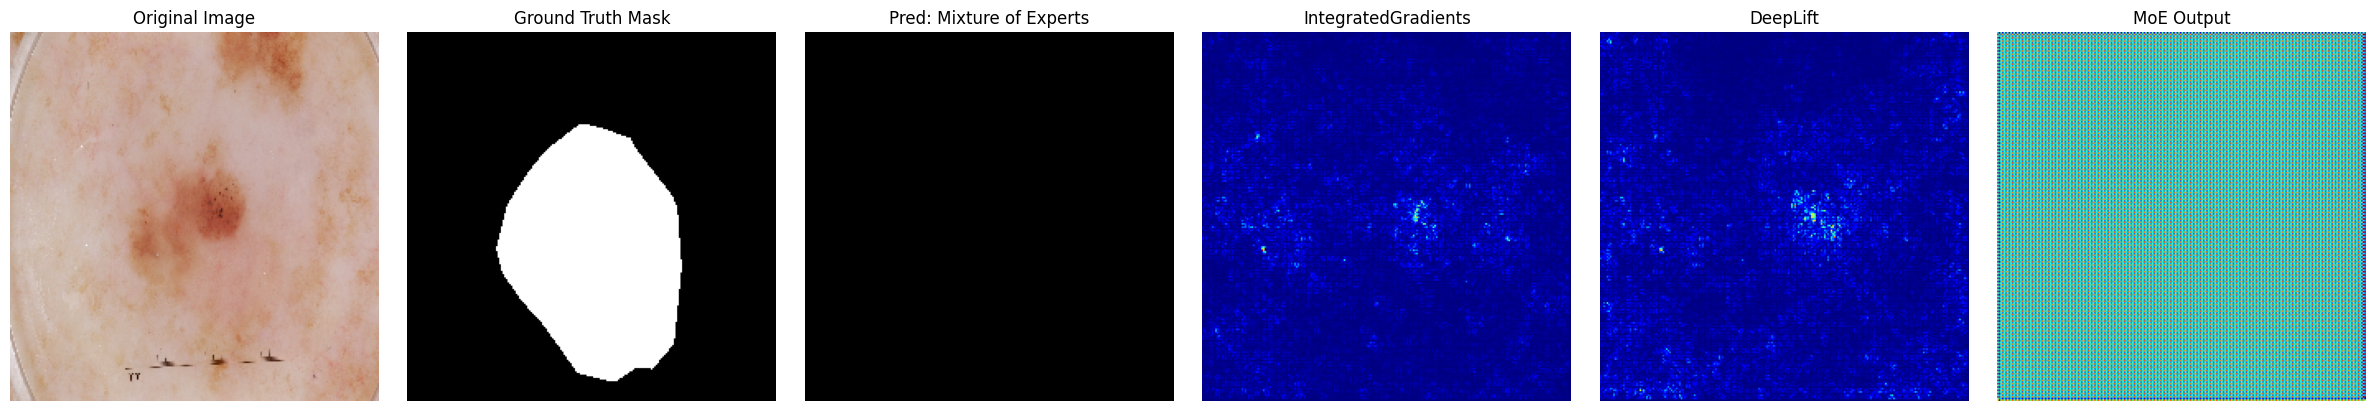

In [16]:
# --- Pipeline Variant 2: Mixture of Experts ---

# Reuse the same sample data 'input_tensor'

# 1. Load Model
model_moe = thesisArchitecture_MoE.EnsembleExplanationNetwork(params).to(device)
model_path_moe = "mixture_of_experts.th"

if os.path.exists(model_path_moe):
    print(f"Loading weights from {model_path_moe}")
    # Using strict=False because of potential mismatch in architecture vs saved weights
    # The existing model weights might correspond to a slightly different version of MoE class
    model_moe.load_state_dict(torch.load(model_path_moe, map_location=device), strict=False)
    print("Weights loaded (strict=False)")
else:
    print(f"Warning: {model_path_moe} not found.")

model_moe.eval()

# 2. Run Inference
with torch.no_grad():
    pred_mask_moe, ensemble_expl_moe = model_moe.forward(params, input_tensor)
    
pred_mask_moe_np = pred_mask_moe.squeeze().cpu().numpy()
ensemble_expl_moe_np = ensemble_expl_moe.squeeze().cpu().numpy()

# Added Analysis Logs
print(f"\n--- MoE Results ---")
print(f"Max Prediction Probability: {pred_mask_moe_np.max():.4f}")
print(f"Mean Prediction Probability: {pred_mask_moe_np.mean():.4f}")
print(f"Predicted Mask Active Pixels (>0.5): {np.sum(pred_mask_moe_np > 0.5)}")
print(f"Ensemble Expl Range: [{ensemble_expl_moe_np.min():.4f}, {ensemble_expl_moe_np.max():.4f}]")

# 3. Visualize
# Prepare explanations list
input_expls_moe = list(input_expls[:-1]) # copy input base explanations
input_expls_moe.append(ensemble_expl_moe_np)
method_names_moe = params.XAI_methods + ["MoE Output"]

visualize_pipeline_result(
    original_img_disp, 
    mask_tensor.squeeze().numpy(), 
    pred_mask_moe_np > 0.5, 
    input_expls_moe, 
    "Mixture of Experts", 
    method_names_moe
)

## Variant 3: Standalone Grad-CAM Pipeline

This pipeline ignores the ensemble architectures and runs a standard `Grad-CAM` on the base classification model (SqueezeNet). This is useful for debugging or quick interpretation without the full fusion model overhead.


--- Grad-CAM Results ---
Target Class ID: tensor([0])
Grad-CAM Min/Max: -0.4885 / 0.8658


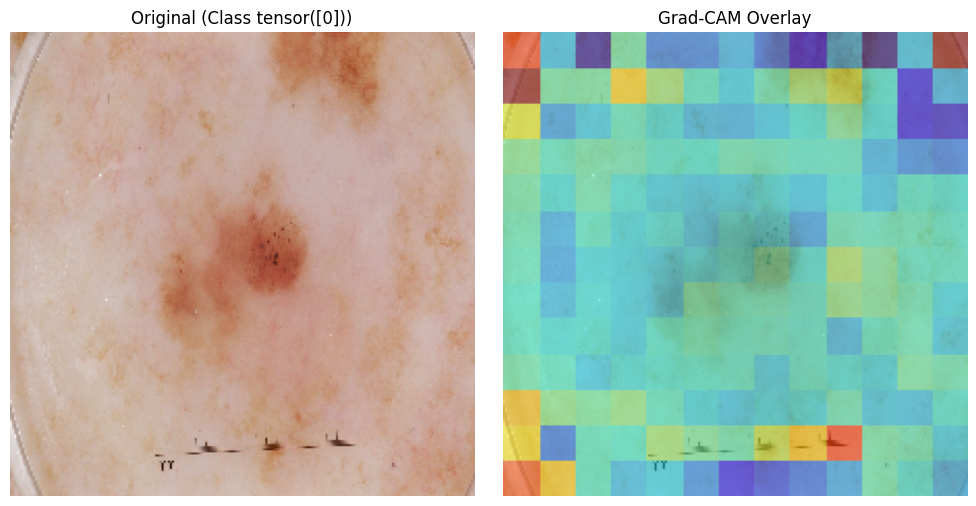

In [17]:
# --- Pipeline Variant 3: Independent Grad-CAM ---

import captum.attr as capt
from captum.attr import LayerGradCam, LayerAttribution

# 1. Setup Base Model
# params.explained_model is already loaded in params (SqueezeNet)
base_model = params.explained_model.to(device)
base_model.eval()

# 2. Load and Prepare Image (reuse the one from dataset)
# original_img_raw is (H, W, 3) numpy array
# Need (1, 3, H, W) tensor
input_img = torch.from_numpy(original_img_raw).permute(2, 0, 1).unsqueeze(0).float().to(device)

target_class = class_id # The ground truth class from dataset

# 3. Define Layer for GradCAM
# params.gradcam_layer defaults to "classifier.1" for SqueezeNet
layer_name = params.gradcam_layer

from functools import reduce
def get_layer(model, layer_name):
    return reduce(getattr, layer_name.split('.'), model)

target_layer = get_layer(base_model, layer_name)

# 4. Generate Grad-CAM
grad_cam = LayerGradCam(base_model, target_layer)
attr = grad_cam.attribute(input_img, target=target_class)

# Upsample to image size
attr = LayerAttribution.interpolate(attr, params.input_size)
attr_np = attr.detach().cpu().squeeze().numpy()

# Added Analysis Logs
print(f"\n--- Grad-CAM Results ---")
print(f"Target Class ID: {target_class}")
print(f"Grad-CAM Min/Max: {attr_np.min():.4f} / {attr_np.max():.4f}")

# 5. Visualize
plt.figure(figsize=(10, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(original_img_disp)
plt.title(f"Original (Class {target_class})")
plt.axis('off')

# GradCAM
plt.subplot(1, 2, 2)
plt.imshow(original_img_disp)
plt.imshow(attr_np, cmap='jet', alpha=0.5) # Overlay
plt.title("Grad-CAM Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()